#Project Name : FedEx Logistics Performance Analysis



## Project Summary :The FedEx Logistics Performance Analysis project aims to assess and enhance the efficiency of logistics operations using a rich dataset consisting of 10,324 rows and 33 columns. The data includes detailed shipment records such as Project Code, Purchase Order numbers, country of delivery, shipment mode, vendor terms, line item quantities, freight costs, unit prices, and manufacturing sites. By analyzing this comprehensive data, the project identifies patterns in shipping performance, cost variations, and delivery reliability. The objective is to extract actionable insights that can guide strategic improvements in supply chain planning, cost control, and overall logistics performance for FedEx.

# Project Statement:The objective of the FedEx Logistics Performance Analysis project is to analyze operational logistics data to evaluate and enhance the efficiency, reliability, and cost-effectiveness of FedEx’s delivery services.

# GitHub:

In [27]:
import pandas as pd
import numpy as np

# reading the data
data = pd.read_csv("/content/SCMS_Delivery_History_Dataset.csv")


### data exploration

In [28]:
#first five elements of data
data.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [29]:
#last 5 elements of data
data.tail()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03
10323,86823,103-ZW-T30,FPQ-15197,SO-50022,DN-4336,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,36639,72911.61,1.99,0.03,"Cipla, Goa, India",No,Weight Captured Separately,Freight Included in Commodity Cost,85.82


In [30]:
#some data have pattern at the beggining or ending or both so sample helps to understand data better in this case
data.sample(10)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
1575,11318,111-MZ-T01,Pre-PQ Process,SO-30440,DN-1231,Mozambique,PMO - US,From RDC,N/A - From RDC,Truck,...,30,19400,188568.00,9.72,0.32,Mylan (formerly Matrix) Nashik,No,See DN-1231 (ID#:11044),See DN-1231 (ID#:11044),369.59
720,7184,113-ZW-T01,Pre-PQ Process,SCMS-25310,ASN-2632,Zimbabwe,PMO - US,Direct Drop,EXW,Air,...,25,7864,157280.00,20.00,0.80,"Standard Diagnostics, Korea",Yes,2450,18087.86,308.27
3773,32540,102-GY-T30,FPQ-6983,SCMS-97160,ASN-10064,Guyana,PMO - US,Direct Drop,EXW,Air,...,100,418,41800.00,100.00,1.00,Inverness Japan,Yes,205,6455.37,68.97
4962,53971,800-LS-T30,FPQ-13954,SCMS-233580,ASN-25539,Lesotho,PMO - US,Direct Drop,EXW,Air,...,20,2500,80000.00,32.00,1.60,"Trinity Biotech, Plc",Yes,Weight Captured Separately,Invoiced Separately,82.24
8870,85035,104-CI-T30,FPQ-14370,SO-49090,DN-4177,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,30,7500,26625.00,3.55,0.12,Mylan (formerly Matrix) Nashik,No,See DN-4177 (ID#:82804),See DN-4177 (ID#:82804),27.37
6291,77090,105-SS-T30,FPQ-15569,SCMS-272170,ASN-32109,South Sudan,PMO - US,Direct Drop,EXW,Air,...,100,90,8010.00,89.00,0.89,"Alere Medical Co., Ltd.",No,See ASN-32109 (ID#:25915),See ASN-32109 (ID#:25915),9.43
1669,11481,104-CI-T01,Pre-PQ Process,SO-1546,DN-609,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Air,...,30,37039,444838.39,12.01,0.40,"Strides, Bangalore, India.",No,See DN-609 (ID#:11480),See DN-609 (ID#:11480),711.74
8975,85157,151-NG-T30,FPQ-5688,SO-37500,DN-2025,Nigeria,PMO - US,From RDC,N/A - From RDC,Air,...,90,2150,20876.50,9.71,0.11,"Aurobindo Unit III, India",No,See DN-2025 (ID#:83460),See DN-2025 (ID#:83460),45.01
5308,60299,116-ZA-T30,FPQ-14942,SCMS-259074,ASN-31070,South Africa,PMO - US,Direct Drop,DDP,Truck,...,30,6,13.03,2.17,0.07,"Aurobindo Unit III, India",No,Weight Captured Separately,Freight Included in Commodity Cost,0.01
1848,11714,100-CI-T01,Pre-PQ Process,SO-286,DN-71,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,NaN,...,60,68,2995.40,44.05,0.73,"Aurobindo Unit III, India",No,See DN-71 (ID#:11374),See DN-71 (ID#:11374),NaN


In [31]:
#information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [32]:
# statistical analysis or breif about the data
data.describe(include ="all")

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,...,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,...,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,...,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,...,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


In [33]:
# shape of data - number of rows and columns for structured database
data.shape

(10324, 33)

In [34]:
# find the number of missing values/null values
data.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


In [35]:
data['PQ First Sent to Client Date'] = pd.to_datetime(data['PQ First Sent to Client Date'], errors='coerce')
data['PO Sent to Vendor Date'] = pd.to_datetime(data['PO Sent to Vendor Date'], errors='coerce')

# Create duration in days
data['Processing_Days'] = (data['PQ First Sent to Client Date'] - data['PO Sent to Vendor Date']).dt.days

/tmp/ipykernel_15638/1419266031.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['PQ First Sent to Client Date'] = pd.to_datetime(data['PQ First Sent to Client Date'], errors='coerce')
/tmp/ipykernel_15638/1419266031.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['PO Sent to Vendor Date'] = pd.to_datetime(data['PO Sent to Vendor Date'], errors='coerce')


In [36]:
data[["PO Sent to Vendor Date","PQ First Sent to Client Date"]].isnull().mean() * 100
data["PO_Sent_Missing"] = data["PO Sent to Vendor Date"].isnull().astype(int)
data["PQ_Client_Missing"] = data["PQ First Sent to Client Date"].isnull().astype(int)



In [37]:
#number of data items which are duplicated
data.duplicated().sum()

np.int64(0)

In [38]:
data["Shipment Mode"]

,Shipment Mode
0,Air
1,Air
2,Air
3,Air
4,Air
...,...
10319,Truck
10320,Truck
10321,Truck
10322,Truck


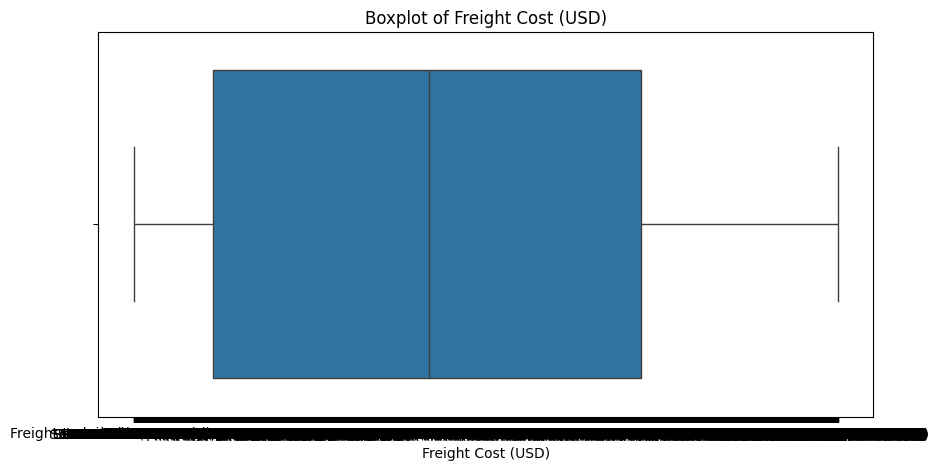

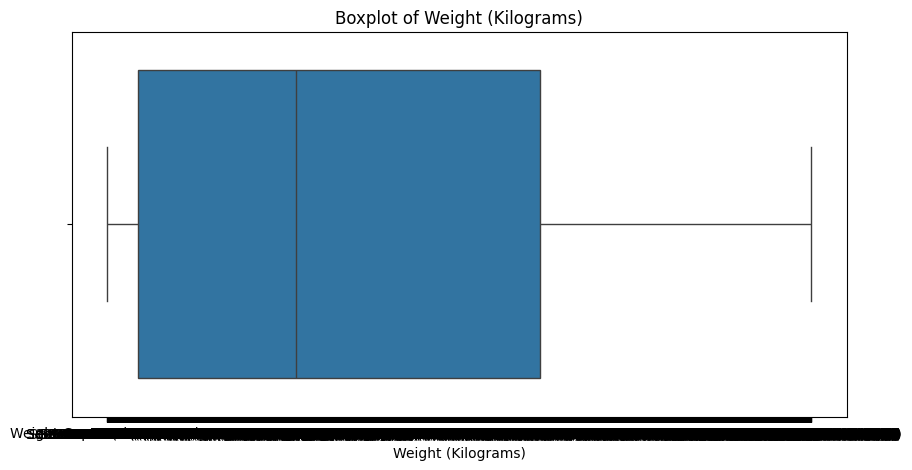

In [39]:
cols_to_check = ["Freight Cost (USD)","Weight (Kilograms)"]
for col in cols_to_check:
  plt.figure(figsize=(10, 5))
  sns.boxplot(x=data[col])
  plt.title(f"Boxplot of {col}")
  plt.show()


In [61]:
def remove_outliers(data,columns):
  q1 =data[columns].quantile(0.25)
  q3 =data[columns].quantile(0.75)
  IQR = q3 - q1
  lower = q1 - 1.5 * IQR
  upper = q3 + 1.5 * IQR
  data = data[(data[columns] >= lower) & (data[columns] <= upper)]
  return data

data = remove_outliers(data,"Freight Cost (USD)")
data = remove_outliers(data,"Weight (Kilograms)")
data = remove_outliers(data,"Processing_Days")

### **Feature Engineering: Extracting Time-Based Features**

To uncover potential seasonal trends or daily patterns, we can extract additional features from our datetime columns.

In [62]:
# Extracting more granular features from date columns

date_cols_for_features = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date',
                          'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']

for col in date_cols_for_features:
    # Ensure the column is datetime (though it should be after previous steps)
    data[col] = pd.to_datetime(data[col], errors='coerce')

    # Extract year, month, day, day of week, and week of year
    data[f'{col}_year'] = data[col].dt.year
    data[f'{col}_month'] = data[col].dt.month
    data[f'{col}_day'] = data[col].dt.day
    data[f'{col}_dayofweek'] = data[col].dt.dayofweek
    data[f'{col}_weekofyear'] = data[col].dt.isocalendar().week.astype(int)

    # Check if the date falls on a weekend (Saturday or Sunday)
    data[f'{col}_is_weekend'] = data[col].dt.dayofweek.isin([5, 6]).astype(int)

print("New time-based features created. Displaying head of the modified DataFrame:")
print(data[["PQ First Sent to Client Date_month", "PQ First Sent to Client Date_dayofweek",
            "Delivered to Client Date_is_weekend"]].head())

New time-based features created. Displaying head of the modified DataFrame:
      PQ First Sent to Client Date_month  \
2681                                  11   
2682                                   5   
2684                                   1   
2685                                   2   
2686                                  10   

      PQ First Sent to Client Date_dayofweek  \
2681                                       2   
2682                                       4   
2684                                       4   
2685                                       4   
2686                                       1   

      Delivered to Client Date_is_weekend  
2681                                    0  
2682                                    0  
2684                                    0  
2685                                    0  
2686                                    0  


In [43]:
data["Shipment Mode"].fillna(data["Shipment Mode"].mode()[0],inplace = True)
data["Dosage"].fillna(data["Dosage"].mode()[0],inplace = True)
data["Line Item Insurance (USD)"].fillna(data["Line Item Insurance (USD)"].mode()[0],inplace = True)

/tmp/ipykernel_15638/1531425179.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Shipment Mode"].fillna(data["Shipment Mode"].mode()[0],inplace = True)
/tmp/ipykernel_15638/1531425179.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [44]:
data["Freight Cost (USD)"].fillna(data["Freight Cost (USD)"].mean(),inplace = True)
data["Weight (Kilograms)"].fillna(data["Weight (Kilograms)"].mean(),inplace = True)

/tmp/ipykernel_15638/618806225.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Freight Cost (USD)"].fillna(data["Freight Cost (USD)"].mean(),inplace = True)
/tmp/ipykernel_15638/618806225.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [45]:
#changing of datatype of some column
datetime = ['Scheduled Delivery Date','Delivered to Client Date','Delivery Recorded Date']
data[datetime] = data[datetime].apply(pd.to_datetime,errors = "coerce")
numeric = ['Weight (Kilograms)', 'Freight Cost (USD)']
data[numeric] = data[numeric].apply(pd.to_numeric,errors="coerce")

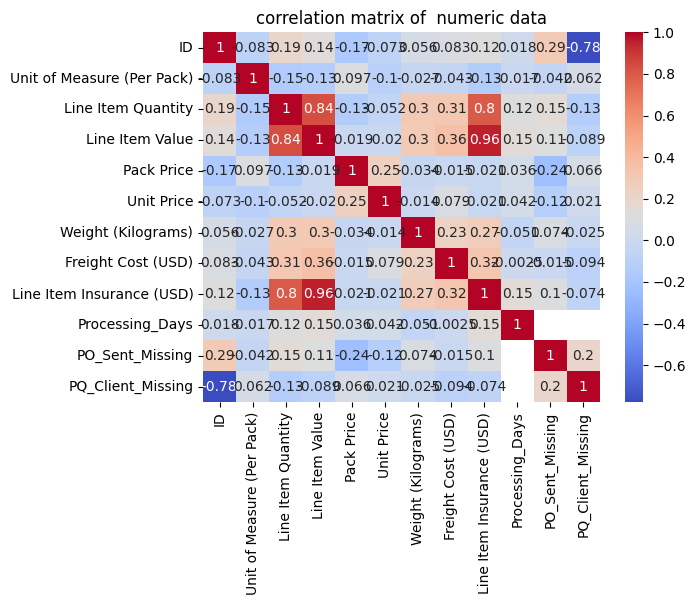

In [46]:
#correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
corr = data.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("correlation matrix of  numeric data")
plt.show()

In [47]:
#defining business question and KPI's

In [48]:
# Question1:Are shipments managed by specific teams (e.g., PMO - US)more likely to be delivered on time compared to others?
data['on_time_delivery'] = (data['Scheduled Delivery Date'] >= data['Delivered to Client Date'])

In [49]:
data["on_time_delivery"]

,on_time_delivery
0,True
1,True
2,True
3,True
4,True
...,...
10319,True
10320,False
10321,True
10322,True


In [50]:
on_time_statistics = data.groupby('Managed By')['on_time_delivery'].mean().sort_values(ascending=False)
on_time_statistics

,on_time_delivery
Managed By,
Ethiopia Field Office,1.000000
Haiti Field Office,1.000000
South Africa Field Office,0.982456
PMO - US,0.884559


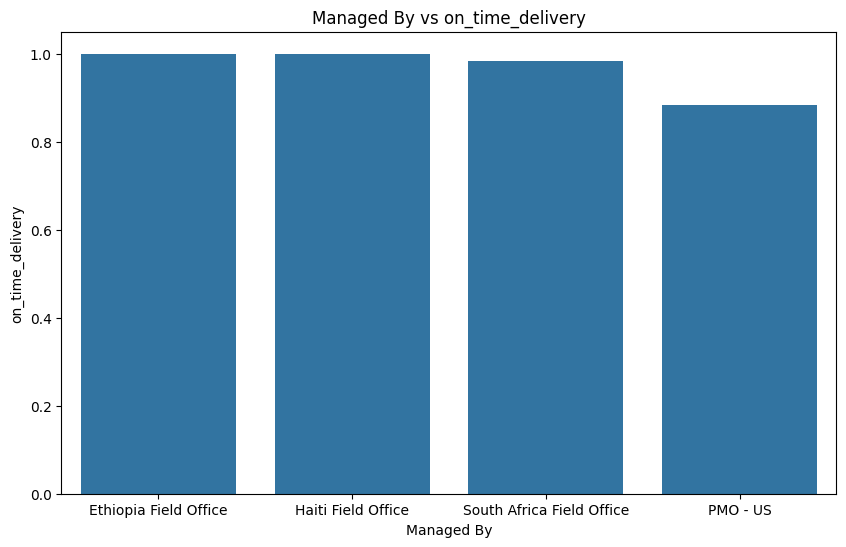

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(data = on_time_statistics.reset_index() ,x = "Managed By",y = "on_time_delivery")
plt.title("Managed By vs on_time_delivery")
plt.ylabel("on_time_delivery")
plt.xlabel("Managed By")
plt.show()

In [52]:
question2 :''' Does the shipment mode (air,sea, etc.) influence the likelihoodof meeting the scheduled delivery date'''
data["on_time_delivery_shipment"] = (data["Delivered to Client Date"]<=data["Scheduled Delivery Date"])
on_time_delivery_shipment= data.groupby("Shipment Mode")["on_time_delivery_shipment"].mean().sort_values(ascending=False)
on_time_delivery_shipment



,on_time_delivery_shipment
Shipment Mode,
Air,0.908698
Air Charter,0.884615
Truck,0.839223
Ocean,0.824798


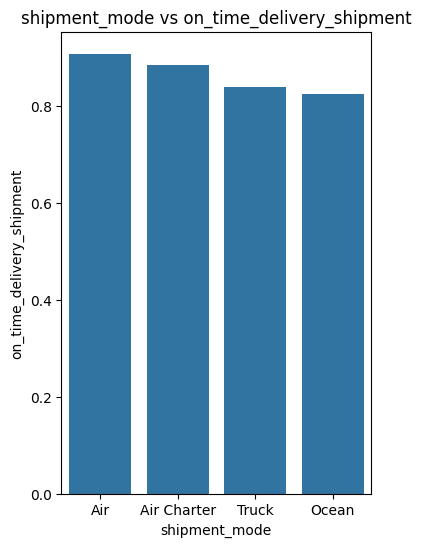

In [53]:
plt.figure(figsize=(4,6))
sns.barplot(data=on_time_delivery_shipment.reset_index(),x="Shipment Mode",y ="on_time_delivery_shipment")
plt.title("shipment_mode vs on_time_delivery_shipment")
plt.ylabel("on_time_delivery_shipment")
plt.xlabel("shipment_mode")
plt.show()

In [54]:
question2:'''Do shipments from certain countries experience more delays compared to others?'''
data["delay_time"] = (data["Delivered to Client Date"] - data["Scheduled Delivery Date"]).dt.days
data["delays"] = (data["Delivered to Client Date"] <= data["Scheduled Delivery Date"])
delays = data.groupby("Country")["delays"].mean().sort_values(ascending=False)
delays

,delays
Country,
Afghanistan,1.000000
Angola,1.000000
Belize,1.000000
Burkina Faso,1.000000
Lebanon,1.000000
Lesotho,1.000000
Liberia,1.000000
Malawi,1.000000
Mali,1.000000


In [55]:
data["delay_time"] = data["delay_time"].clip(lower = 0)
avg_delay_time = data.groupby("Country")["delay_time"].mean().sort_values(ascending=False)
avg_delay_time


,delay_time
Country,
"Congo, DRC",16.348348
Togo,8.000000
Benin,4.692308
Burundi,4.357143
Mozambique,3.858954
Ghana,3.500000
South Africa,3.296586
Tanzania,2.649326
Zambia,2.547584


In [56]:
#question3 :Does the shipment mode impact the frequency of on-time deliveries?
data["OnTime"] = (data["Scheduled Delivery Date"] <= data["Delivered to Client Date"]).astype(int)
ontime_summary = data.groupby("Shipment Mode")["OnTime"].agg(["mean","count"])
print(ontime_summary)


                   mean  count
Shipment Mode                 
Air            0.813070   6473
Air Charter    0.304615    650
Ocean          0.959569    371
Truck          0.598233   2830


<Axes: xlabel='Shipment Mode', ylabel='OnTime'>

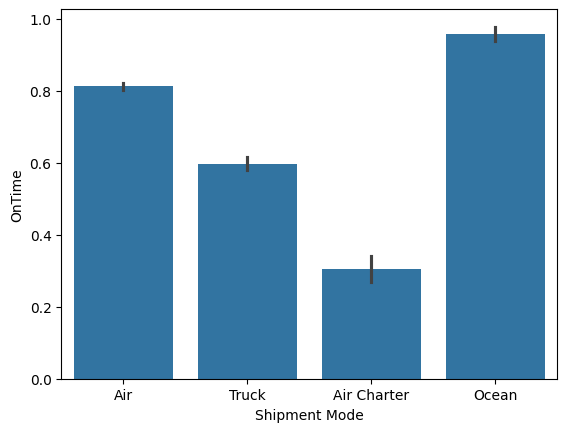

In [57]:
import seaborn as sns
sns.barplot(x="Shipment Mode", y="OnTime", data=data)

In [58]:
list(data.columns)

['ID',
 'Project Code',
 'PQ #',
 'PO / SO #',
 'ASN/DN #',
 'Country',
 'Managed By',
 'Fulfill Via',
 'Vendor INCO Term',
 'Shipment Mode',
 'PQ First Sent to Client Date',
 'PO Sent to Vendor Date',
 'Scheduled Delivery Date',
 'Delivered to Client Date',
 'Delivery Recorded Date',
 'Product Group',
 'Sub Classification',
 'Vendor',
 'Item Description',
 'Molecule/Test Type',
 'Brand',
 'Dosage',
 'Dosage Form',
 'Unit of Measure (Per Pack)',
 'Line Item Quantity',
 'Line Item Value',
 'Pack Price',
 'Unit Price',
 'Manufacturing Site',
 'First Line Designation',
 'Weight (Kilograms)',
 'Freight Cost (USD)',
 'Line Item Insurance (USD)',
 'Processing_Days',
 'PO_Sent_Missing',
 'PQ_Client_Missing',
 'on_time_delivery',
 'on_time_delivery_shipment',
 'delay_time',
 'delays',
 'OnTime']

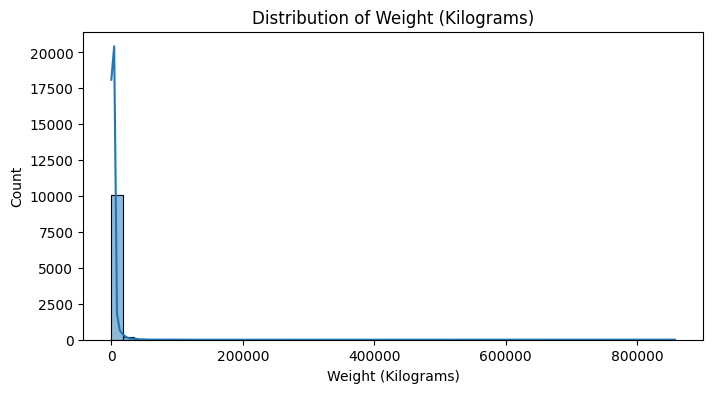

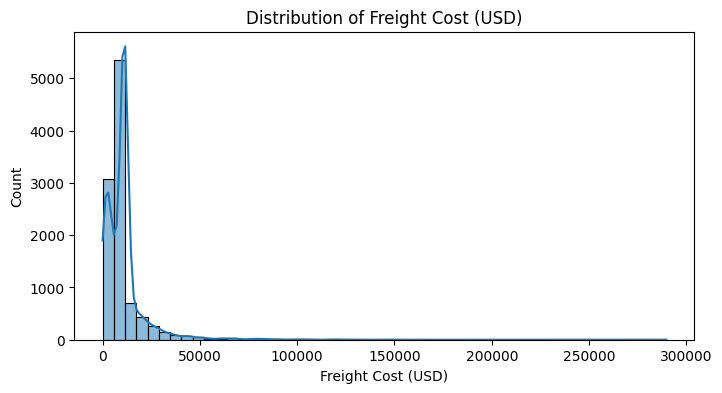

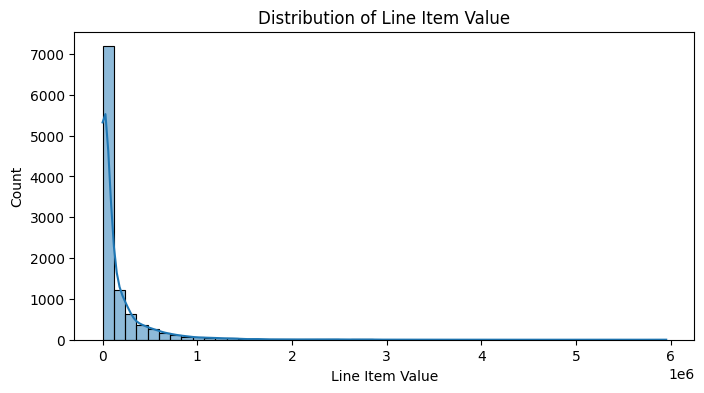

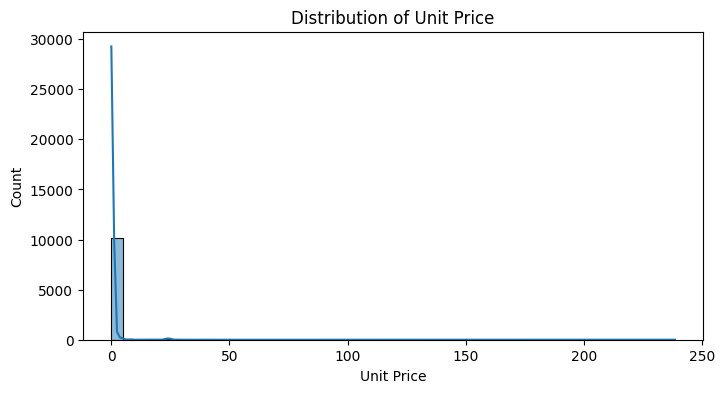

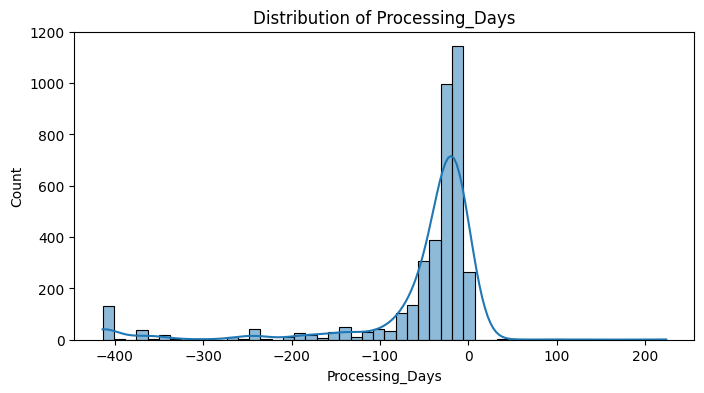

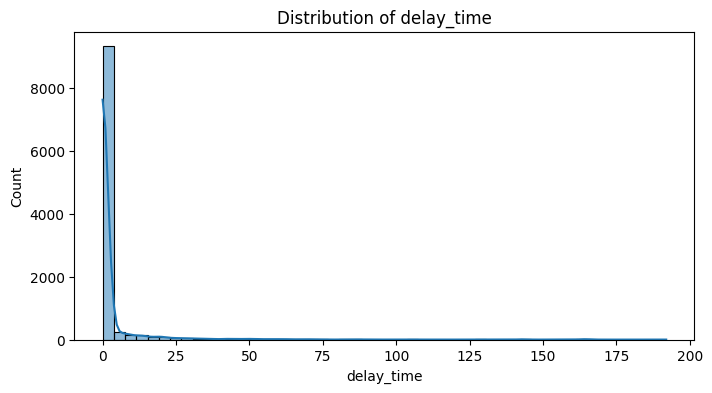

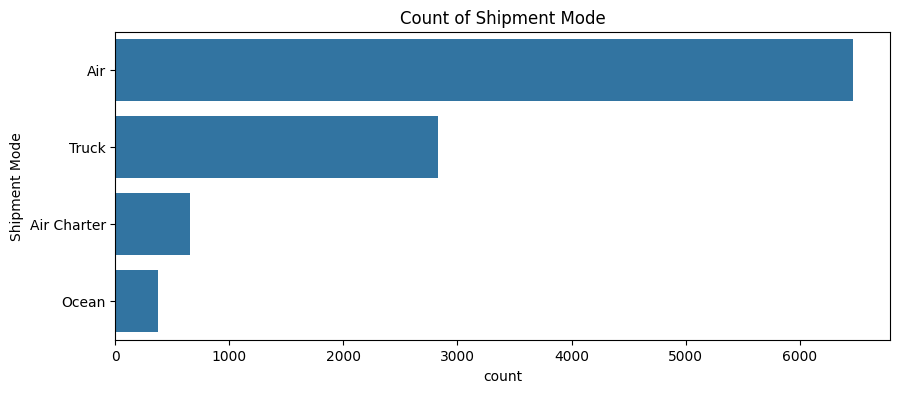

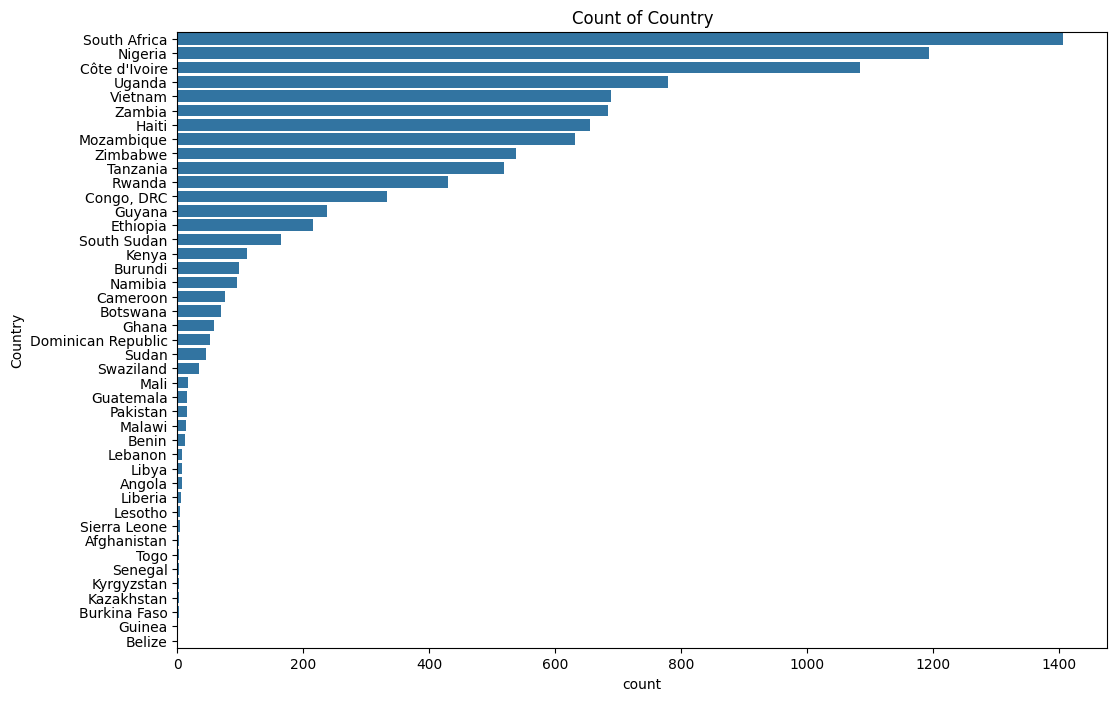

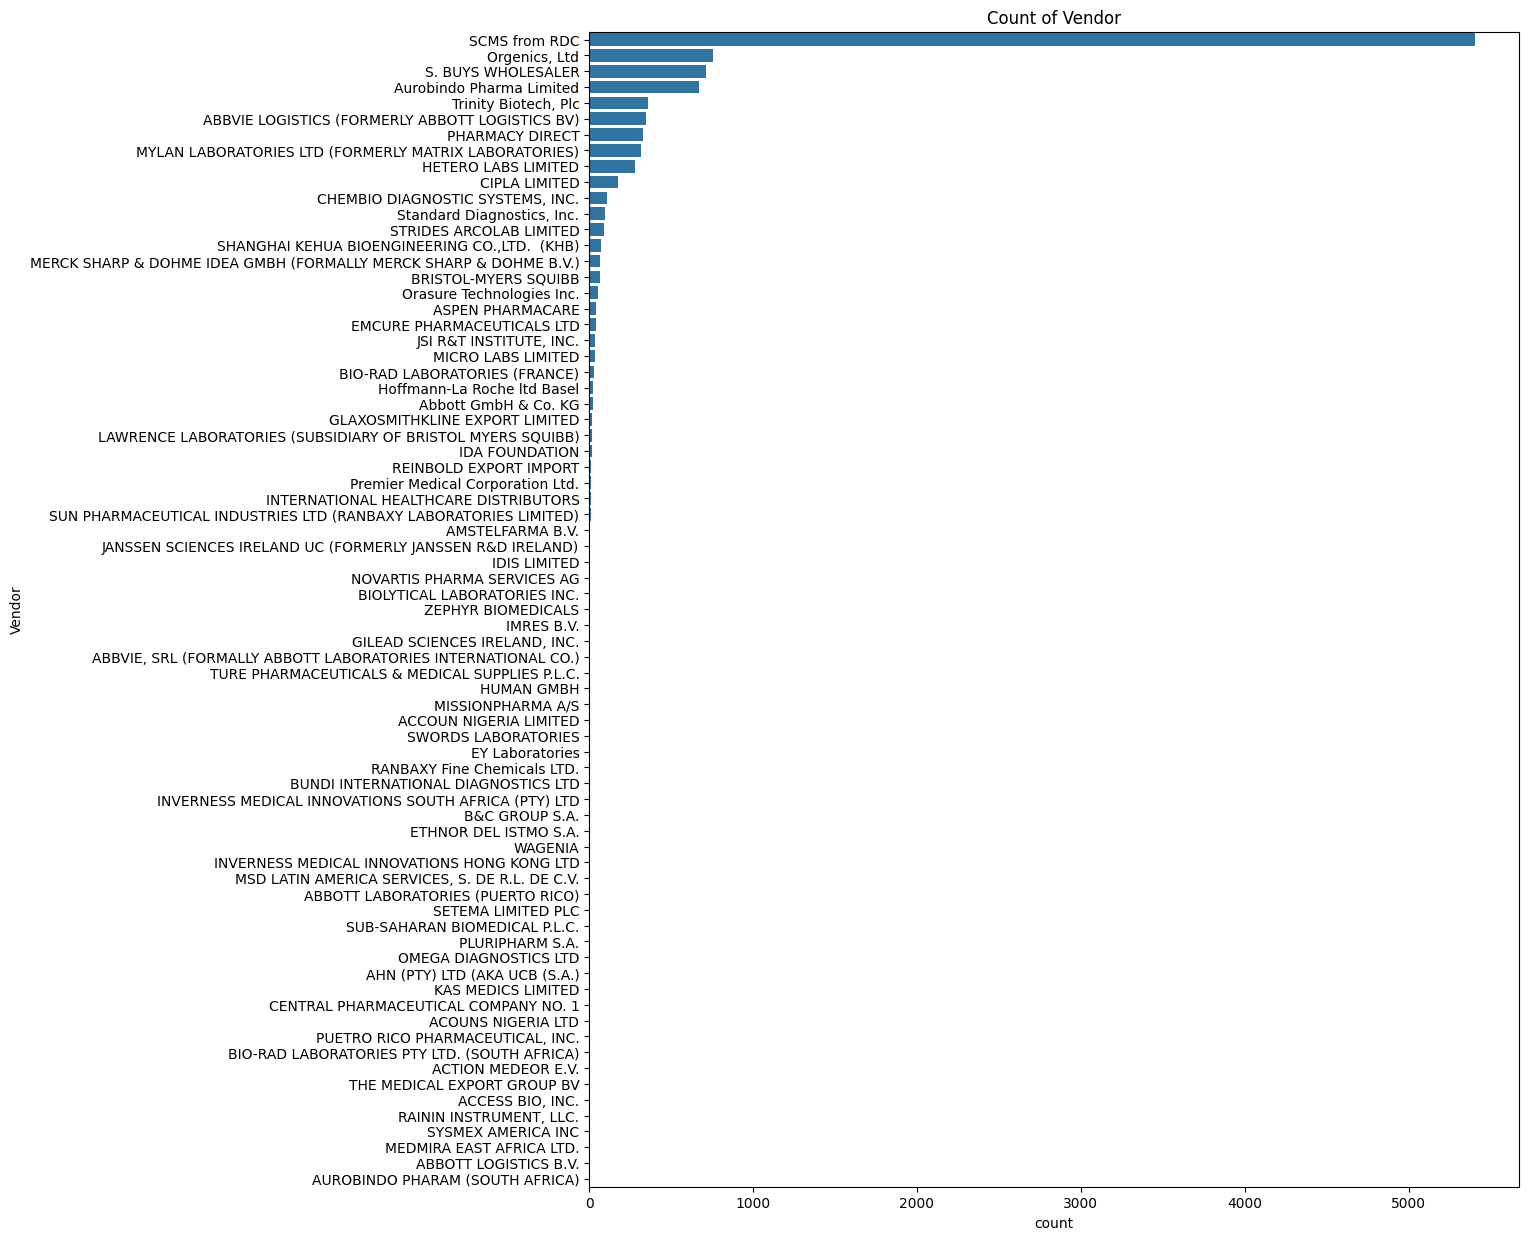

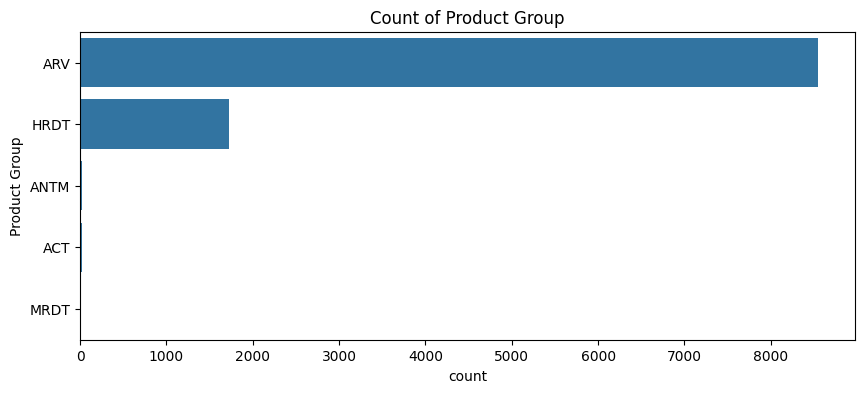

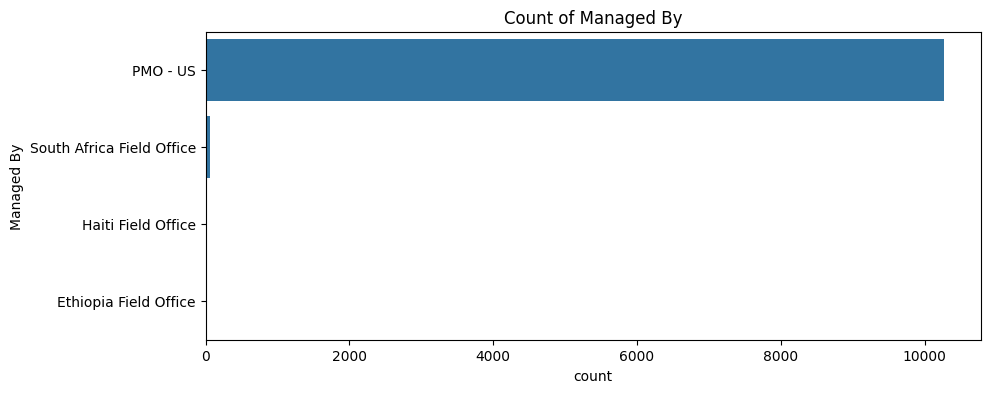

In [59]:
# ==============================================
# 1. Univariate Analysis (distributions)
# ==============================================
import matplotlib.pyplot as plt
import seaborn as sns

# numeric columns
numeric_cols = ["Weight (Kilograms)", "Freight Cost (USD)",
                "Line Item Value", "Unit Price", "Processing_Days", "delay_time"]

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# categorical columns
categorical_cols = ["Shipment Mode", "Country", "Vendor", "Product Group", "Managed By"]

for col in categorical_cols:
    plt.figure(figsize=(12, 8) if col == "Country" else (12, 15) if col == "Vendor" else (10,4))
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.show()

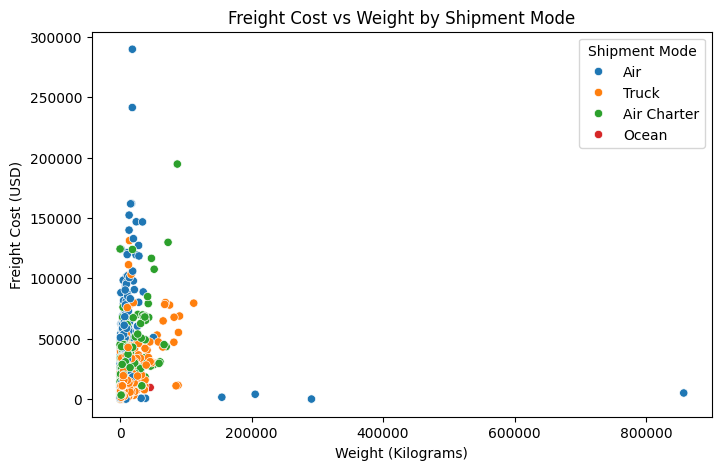

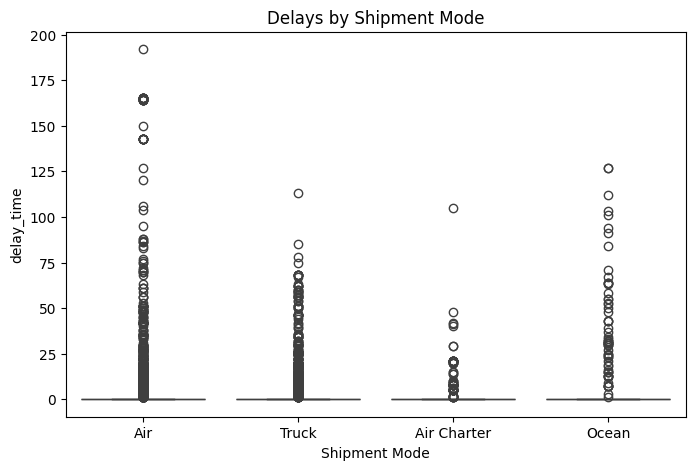

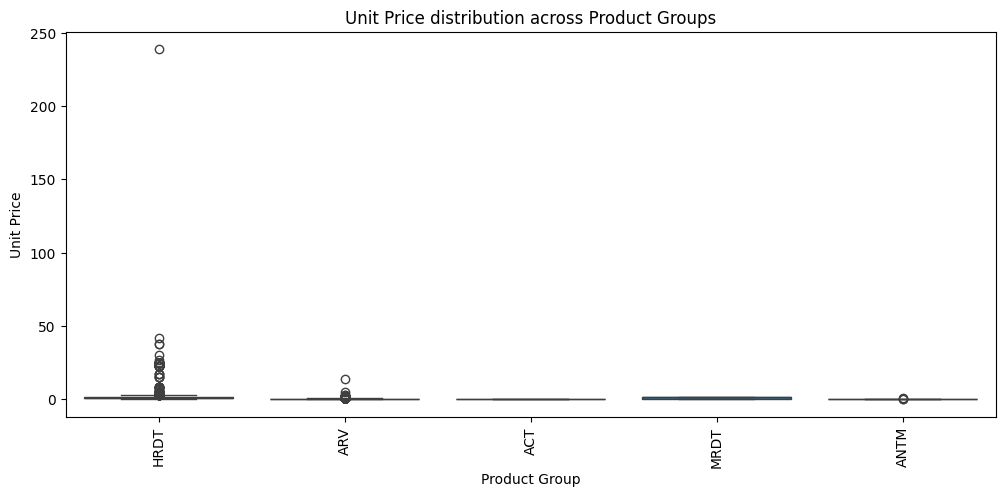

In [60]:
# ==============================================
# 2. Bivariate Analysis
# ==============================================
# Cost vs Weight (are costs proportional?)
plt.figure(figsize=(8,5))
sns.scatterplot(x="Weight (Kilograms)", y="Freight Cost (USD)", hue="Shipment Mode", data=data)
plt.title("Freight Cost vs Weight by Shipment Mode")
plt.show()

# Delay by Shipment Mode
plt.figure(figsize=(8,5))
sns.boxplot(x="Shipment Mode", y="delay_time", data=data)
plt.title("Delays by Shipment Mode")
plt.show()

# Unit Price vs Product Group
plt.figure(figsize=(12,5))
sns.boxplot(x="Product Group", y="Unit Price", data=data)
plt.xticks(rotation=90)
plt.title("Unit Price distribution across Product Groups")
plt.show()


### 3. Analysis of Time-Based Features

Let's analyze the newly engineered time-based features to understand their impact on key metrics like `Processing_Days` and `on_time_delivery`.

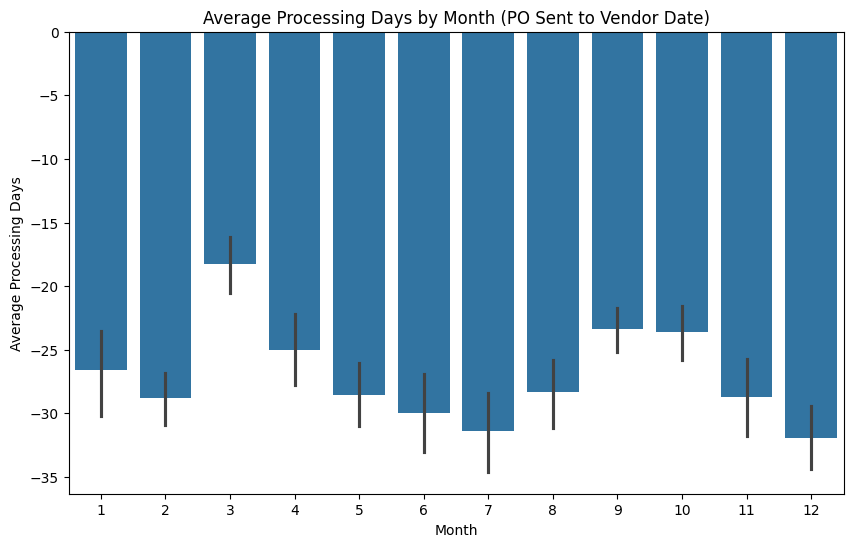

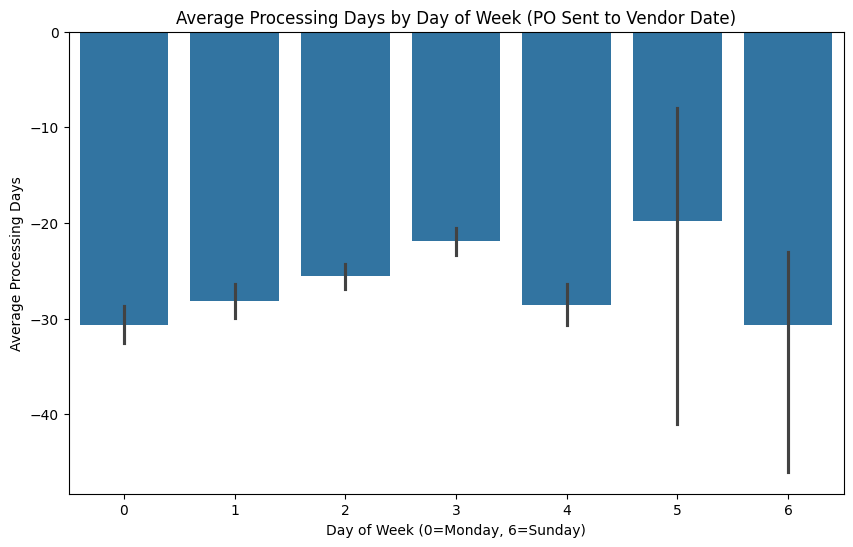

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average Processing Days by Month
plt.figure(figsize=(10, 6))
sns.barplot(x='PO Sent to Vendor Date_month', y='Processing_Days', data=data)
plt.title('Average Processing Days by Month (PO Sent to Vendor Date)')
plt.xlabel('Month')
plt.ylabel('Average Processing Days')
plt.show()

# Average Processing Days by Day of Week
plt.figure(figsize=(10, 6))
sns.barplot(x='PO Sent to Vendor Date_dayofweek', y='Processing_Days', data=data)
plt.title('Average Processing Days by Day of Week (PO Sent to Vendor Date)')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Processing Days')
plt.show()

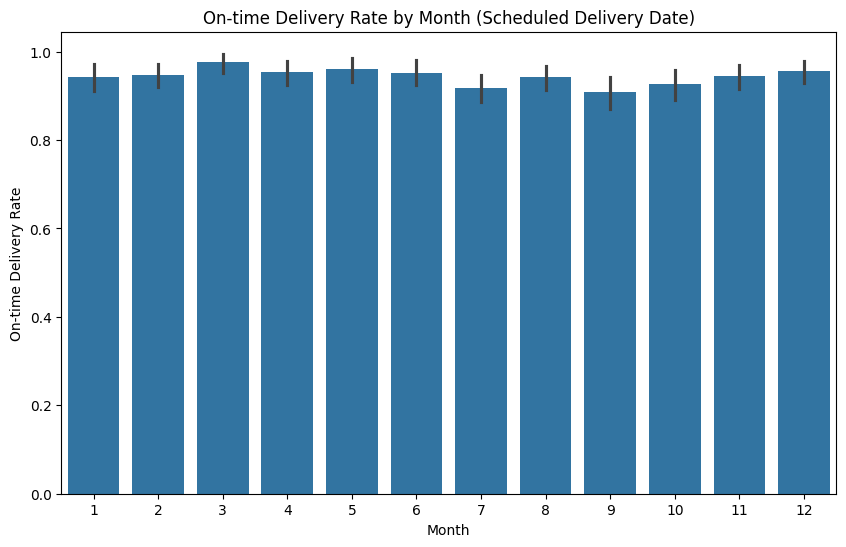

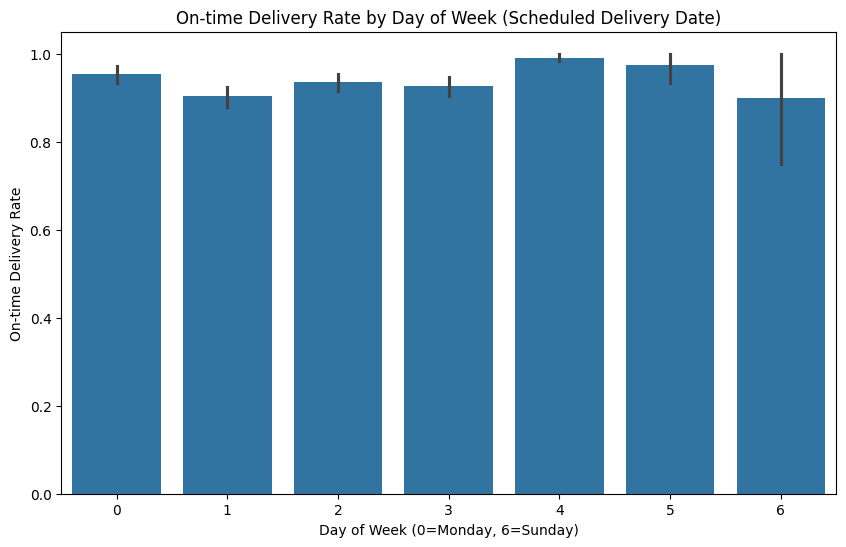

In [64]:
# On-time Delivery Rate by Month (Scheduled Delivery Date)
plt.figure(figsize=(10, 6))
sns.barplot(x='Scheduled Delivery Date_month', y='on_time_delivery', data=data)
plt.title('On-time Delivery Rate by Month (Scheduled Delivery Date)')
plt.xlabel('Month')
plt.ylabel('On-time Delivery Rate')
plt.show()

# On-time Delivery Rate by Day of Week (Scheduled Delivery Date)
plt.figure(figsize=(10, 6))
sns.barplot(x='Scheduled Delivery Date_dayofweek', y='on_time_delivery', data=data)
plt.title('On-time Delivery Rate by Day of Week (Scheduled Delivery Date)')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('On-time Delivery Rate')
plt.show()

### 4. Investigation of Negative Processing Days

As noted previously, `Processing_Days` should not be negative. Let's investigate these occurrences and decide on a handling strategy.

In [65]:
# Count records where Processing_Days is negative
negative_processing_days_count = data[data['Processing_Days'] < 0].shape[0]
print(f"Number of records with negative Processing_Days: {negative_processing_days_count}")

# Display some examples of negative Processing_Days
if negative_processing_days_count > 0:
    print("\nExamples of records with negative Processing_Days:")
    print(data[data['Processing_Days'] < 0][['PO Sent to Vendor Date', 'PQ First Sent to Client Date', 'Processing_Days']].head())

Number of records with negative Processing_Days: 2927

Examples of records with negative Processing_Days:
     PO Sent to Vendor Date PQ First Sent to Client Date  Processing_Days
2681             2009-12-02                   2009-11-18            -14.0
2682             2013-05-15                   2013-05-03            -12.0
2684             2012-02-24                   2012-01-06            -49.0
2685             2013-04-01                   2013-02-22            -38.0
2686             2014-11-07                   2014-10-28            -10.0


### 5. Handling Negative Processing Days

To ensure data integrity, we will set all negative `Processing_Days` values to 0, as processing time cannot be negative. This might indicate cases where the 'PQ First Sent to Client Date' was recorded before the 'PO Sent to Vendor Date' due to data entry issues or other discrepancies.

In [66]:
# Set negative Processing_Days to 0
data['Processing_Days'] = data['Processing_Days'].apply(lambda x: max(x, 0))

# Verify the change
print(f"Number of records with negative Processing_Days after correction: {data[data['Processing_Days'] < 0].shape[0]}")
print("Verifying a few records around the previous examples (if they still exist and were affected):")
print(data[data['Processing_Days'] == 0][['PO Sent to Vendor Date', 'PQ First Sent to Client Date', 'Processing_Days']].head())

Number of records with negative Processing_Days after correction: 0
Verifying a few records around the previous examples (if they still exist and were affected):
     PO Sent to Vendor Date PQ First Sent to Client Date  Processing_Days
2681             2009-12-02                   2009-11-18              0.0
2682             2013-05-15                   2013-05-03              0.0
2684             2012-02-24                   2012-01-06              0.0
2685             2013-04-01                   2013-02-22              0.0
2686             2014-11-07                   2014-10-28              0.0


### 6. Deeper Analysis of Corrected Processing Days

With `Processing_Days` now corrected (non-negative), let's re-examine its distribution and explore its relationship with key categorical features to identify patterns in processing efficiency.

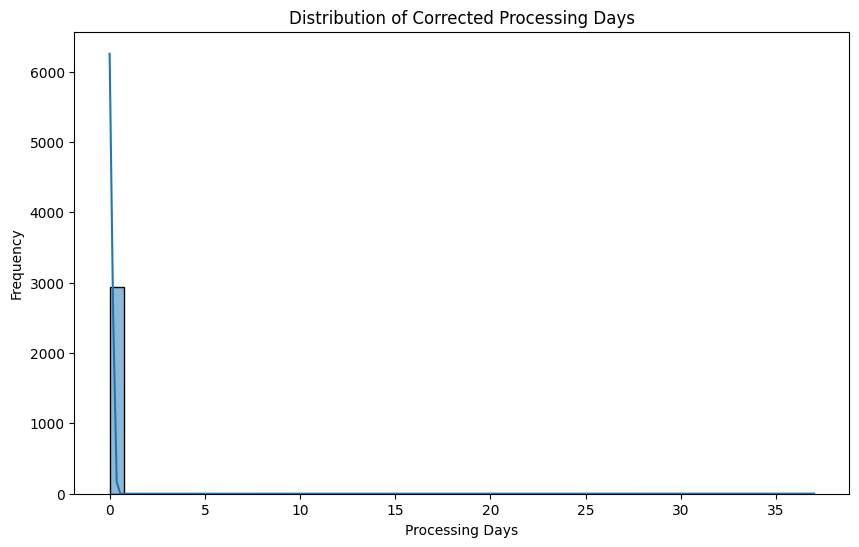

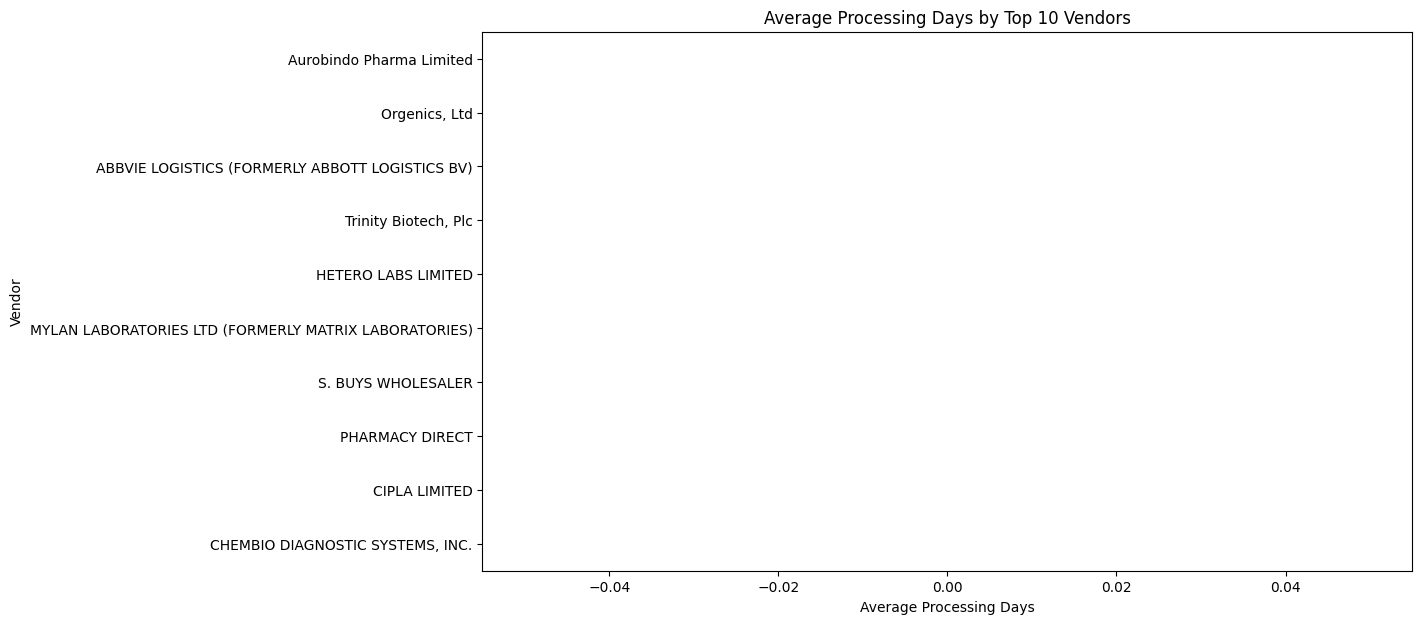

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of corrected Processing_Days
plt.figure(figsize=(10, 6))
sns.histplot(data['Processing_Days'], bins=50, kde=True)
plt.title('Distribution of Corrected Processing Days')
plt.xlabel('Processing Days')
plt.ylabel('Frequency')
plt.show()

# Average Processing Days by Vendor (Top 10 Vendors)
plt.figure(figsize=(12, 7))
top_10_vendors = data['Vendor'].value_counts().nlargest(10).index
sns.barplot(x='Processing_Days', y='Vendor', data=data[data['Vendor'].isin(top_10_vendors)], order=top_10_vendors)
plt.title('Average Processing Days by Top 10 Vendors')
plt.xlabel('Average Processing Days')
plt.ylabel('Vendor')
plt.show()

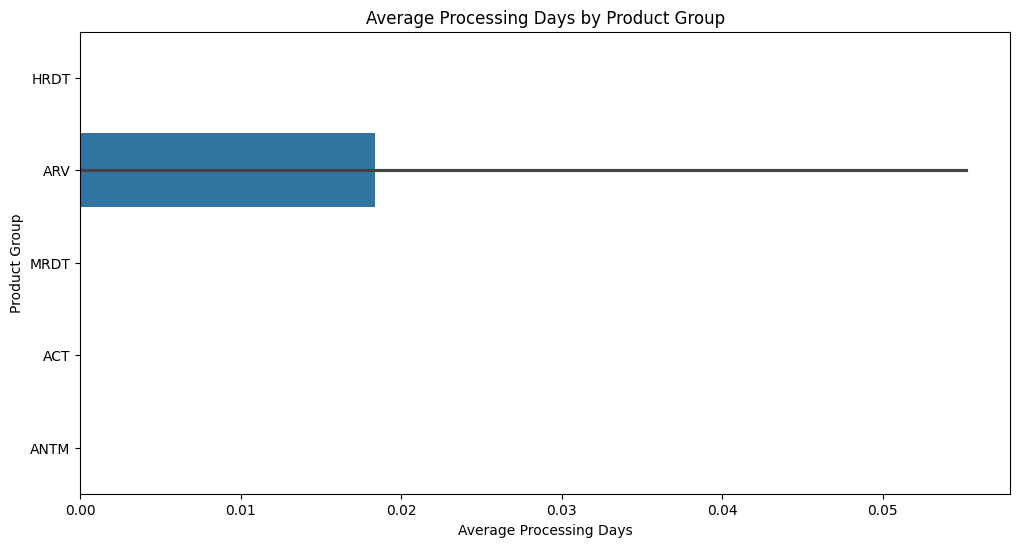

In [68]:
# Average Processing Days by Product Group
plt.figure(figsize=(12, 6))
sns.barplot(x='Processing_Days', y='Product Group', data=data)
plt.title('Average Processing Days by Product Group')
plt.xlabel('Average Processing Days')
plt.ylabel('Product Group')
plt.show()

### 7. Cost Analysis: Calculating and Analyzing 'Cost per Unit'

To standardize cost comparison, let's calculate 'Cost per Unit' and analyze its distribution across relevant categories.

/tmp/ipykernel_15638/3930085264.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Cost per Unit'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_15638/3930085264.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

Head of data with new 'Cost per Unit' column:
      Line Item Value  Line Item Quantity  Cost per Unit
2681             80.0                   1          80.00
2682          74871.0               11092           6.75
2684            685.4                 298           2.30
2685           8010.0                  90          89.00
2686           2740.0                 400           6.85


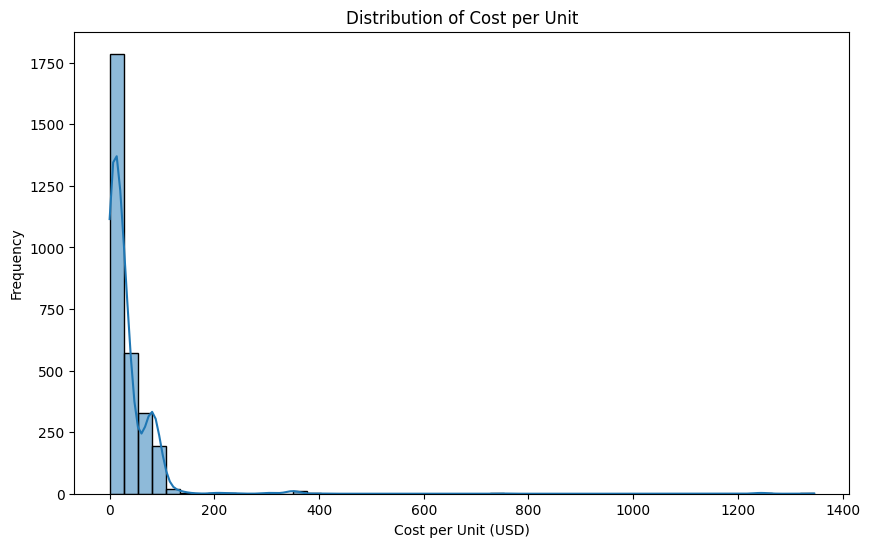

In [69]:
# Calculate 'Cost per Unit'
data['Cost per Unit'] = data['Line Item Value'] / data['Line Item Quantity']

# Handle potential division by zero if Line Item Quantity is 0
data['Cost per Unit'].replace([np.inf, -np.inf], np.nan, inplace=True)
data['Cost per Unit'].fillna(0, inplace=True) # Replace NaN (from division by zero) with 0 or a suitable value

print("Head of data with new 'Cost per Unit' column:")
print(data[['Line Item Value', 'Line Item Quantity', 'Cost per Unit']].head())

# Distribution of Cost per Unit
plt.figure(figsize=(10, 6))
sns.histplot(data['Cost per Unit'], bins=50, kde=True)
plt.title('Distribution of Cost per Unit')
plt.xlabel('Cost per Unit (USD)')
plt.ylabel('Frequency')
plt.show()

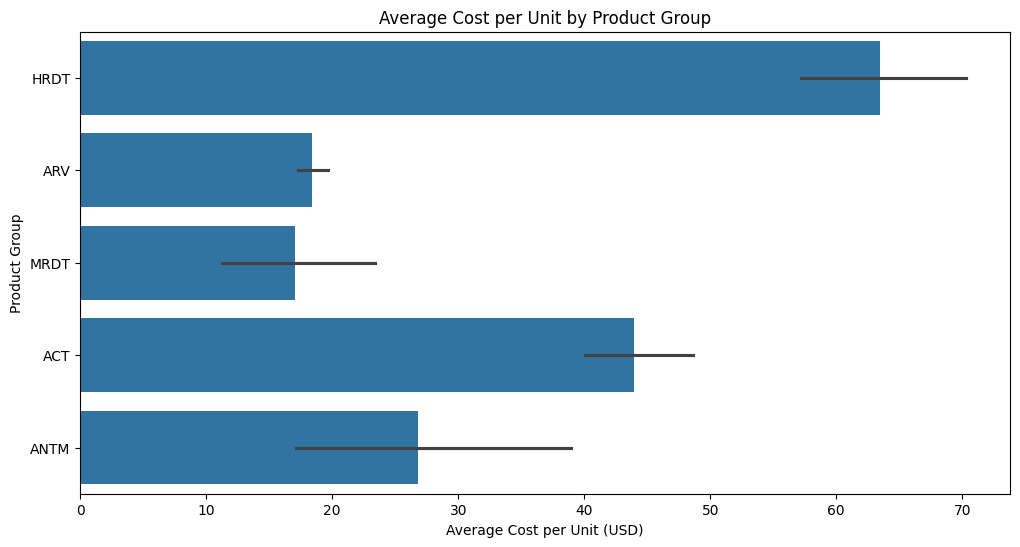

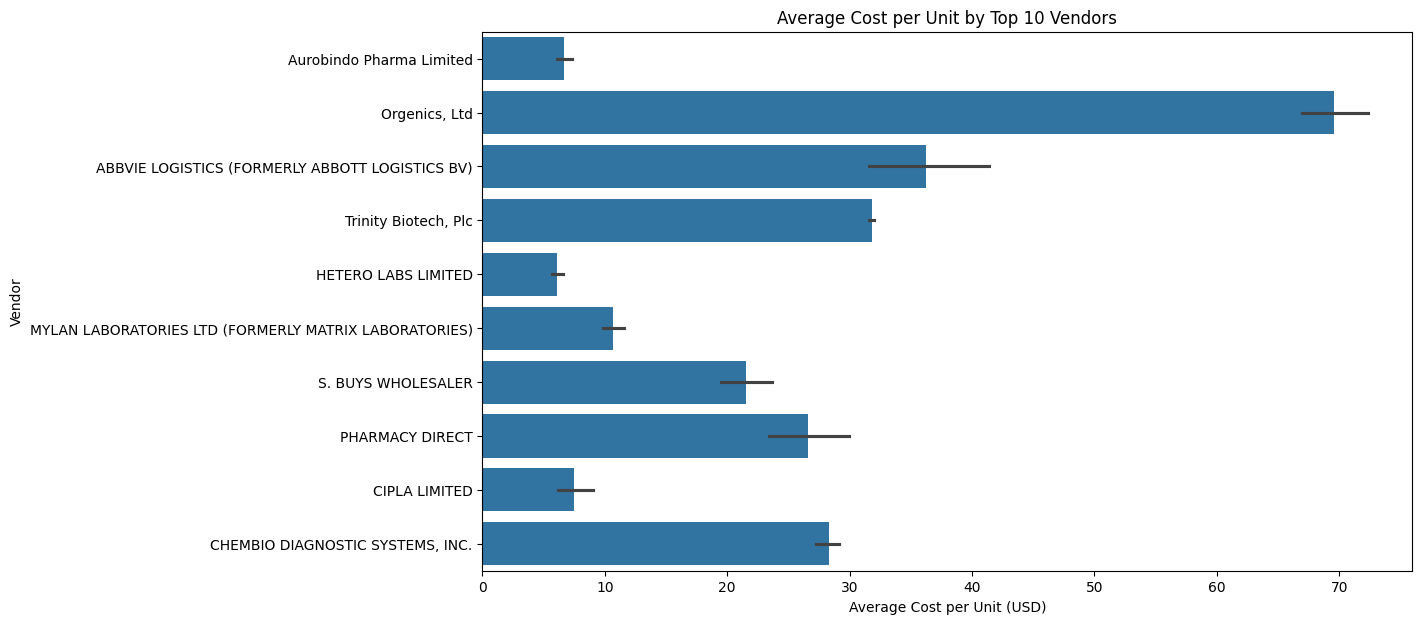

In [70]:
# Average Cost per Unit by Product Group
plt.figure(figsize=(12, 6))
sns.barplot(x='Cost per Unit', y='Product Group', data=data)
plt.title('Average Cost per Unit by Product Group')
plt.xlabel('Average Cost per Unit (USD)')
plt.ylabel('Product Group')
plt.show()

# Average Cost per Unit by Vendor (Top 10 Vendors)
plt.figure(figsize=(12, 7))
top_10_vendors_cost = data['Vendor'].value_counts().nlargest(10).index
sns.barplot(x='Cost per Unit', y='Vendor', data=data[data['Vendor'].isin(top_10_vendors_cost)], order=top_10_vendors_cost)
plt.title('Average Cost per Unit by Top 10 Vendors')
plt.xlabel('Average Cost per Unit (USD)')
plt.ylabel('Vendor')
plt.show()

### 8. Geographical Visualizations

Let's visualize logistics performance metrics on a map to identify geographical patterns and disparities in `Processing_Days` and `on_time_delivery` by country.

In [71]:
import plotly.express as px

# Calculate average Processing_Days by Country
avg_processing_days_by_country = data.groupby('Country')['Processing_Days'].mean().reset_index()

# Plotting Average Processing Days by Country on a Choropleth map
fig_processing_days = px.choropleth(
    avg_processing_days_by_country,
    locations="Country",
    locationmode='country names',
    color="Processing_Days",
    hover_name="Country",
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Average Processing Days by Country'
)
fig_processing_days.show()

# Calculate on-time delivery rate by Country
on_time_delivery_by_country = data.groupby('Country')['on_time_delivery'].mean().reset_index()

# Plotting On-time Delivery Rate by Country on a Choropleth map
fig_on_time_delivery = px.choropleth(
    on_time_delivery_by_country,
    locations="Country",
    locationmode='country names',
    color="on_time_delivery",
    hover_name="Country",
    color_continuous_scale=px.colors.sequential.Viridis,
    title='On-time Delivery Rate by Country'
)
fig_on_time_delivery.show()

# Solutions and Approaches for FedEx Logistics Performance Improvement

---

## 1. Data Quality and Process Improvement

*   **Summary of Findings**: We identified and corrected negative `Processing_Days` values, which indicates potential data entry errors where the 'PO Sent to Vendor Date' was recorded after 'PQ First Sent to Client Date'. This highlights a need for better data validation.

*   **Solution**: Implement robust data validation checks at the point of entry for date fields to prevent logical inconsistencies. Improve data collection for fields like 'Weight (Kilograms)' and 'Freight Cost (USD)' which sometimes contained non-numeric strings.

*   **Approach**:
    *   Develop automated scripts to flag or correct illogical date entries (e.g., if `PO Sent to Vendor Date` is after `PQ First Sent to Client Date`, the `Processing_Days` should be set to 0 or flagged for review).
    *   Conduct training for data entry personnel on the importance of accurate and consistent date recording.
    *   Standardize the input format for 'Weight (Kilograms)' and 'Freight Cost (USD)' to ensure all entries are quantifiable numbers.

## 2. Vendor Performance Optimization

*   **Summary of Findings**: Our analysis of average `Processing_Days` and `Cost per Unit` by vendor revealed significant variations. Some vendors consistently show longer processing times or higher costs, while others are more efficient.

*   **Solution**: Identify and collaborate with vendors exhibiting suboptimal performance in terms of processing time and cost efficiency to drive improvements.

*   **Approach**:
    *   Establish clear Key Performance Indicators (KPIs) for vendors related to `Processing_Days`, `on_time_delivery` rates, and `Cost per Unit`.
    *   Generate regular vendor performance reports and share them to foster transparency and encourage competition.
    *   Initiate discussions with underperforming vendors to understand the root causes of their inefficiencies (e.g., internal processes, communication gaps, lead times) and develop joint action plans for improvement.
    *   Consider implementing a vendor tiering system based on performance, offering incentives for top-tier vendors and support for those needing improvement.

## 3. Shipment Mode and Route Optimization

*   **Summary of Findings**: The on-time delivery rates varied significantly by `Shipment Mode`, with 'Air' generally performing better than 'Truck' or 'Ocean'. Geographical visualizations highlighted specific countries with higher average `Processing_Days` and lower `on_time_delivery` rates.

*   **Solution**: Develop dynamic strategies for selecting shipment modes and routes, taking into account the destination country's performance, urgency, and cost considerations.

*   **Approach**:
    *   Utilize the `on_time_delivery` and `delay_time` analysis by `Shipment Mode` and `Country` to create an informed decision-making framework for route planning.
    *   For countries with identified consistent delays, investigate local logistics infrastructure, customs processes, and the performance of local partners.
    *   Implement a system that suggests optimal shipment modes and routes based on historical performance data, considering factors like desired delivery speed, budget, and reliability for specific regions.
    *   Explore consolidation opportunities for shipments to countries with lower volume but higher costs/delays.

## 4. Product Group Specific Logistics Strategies

*   **Summary of Findings**: We observed variations in average `Processing_Days` and `Cost per Unit` across different `Product Group` categories. This suggests that a one-size-fits-all logistics approach may not be optimal.

*   **Solution**: Tailor logistics and supply chain strategies to the unique requirements and characteristics of each product group.

*   **Approach**:
    *   Categorize product groups based on their impact on `Processing_Days` and `Cost per Unit`, as well as other factors like perishability, value, and fragility.
    *   For high-value or time-sensitive product groups, prioritize faster shipment modes, premium vendors, and potentially dedicated logistics channels.
    *   For less time-critical or commodity product groups, focus on optimizing for cost efficiency, even if it means slightly longer transit times.
    *   Develop specific inventory management strategies for each product group to balance stock levels with demand and lead times.

## 5. Advanced Analytics and Predictive Modeling

*   **Summary of Findings**: The various features engineered and relationships explored (e.g., time-based features, `Processing_Days`, `on_time_delivery`) lay a strong foundation for predictive capabilities.

*   **Solution**: Leverage machine learning and advanced analytical techniques to forecast demand, predict potential delays, and optimize resource allocation proactively.

*   **Approach**:
    *   **Predictive Delay Model**: Build a machine learning model using historical data on `Processing_Days`, `delay_time`, `Shipment Mode`, `Country`, `Vendor`, and all engineered time-based features to predict the likelihood and potential duration of delays for future shipments.
    *   **Demand Forecasting**: Develop forecasting models for various product groups and regions using historical `Line Item Quantity` and time-based features to enable better inventory planning and resource allocation.
    *   **Cost Optimization Models**: Explore optimization algorithms that can suggest the most cost-effective combination of vendors, shipment modes, and routes while meeting service level agreements (SLAs) for delivery times.
    *   **Root Cause Analysis Automation**: Use statistical methods or machine learning to automatically identify the primary drivers behind unexpected delays or cost increases.